In [1]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
#pd.set_option('display.max_rows', None)

In [2]:
# Make output folders
WSLS_output_dir = os.path.join('..','plots','behavioural_pilot','behavioural_modelling','WSLS')
if not os.path.exists(WSLS_output_dir):
    os.makedirs(WSLS_output_dir)
CSIS_output_dir = os.path.join('..','plots','behavioural_pilot','behavioural_modelling','CSIS')
if not os.path.exists(CSIS_output_dir):
    os.makedirs(CSIS_output_dir)

In [3]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')

In [4]:
unique_subject_ids = list(range(900, 915))
unique_sessions = [1]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)
print(recent_results)

['../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-900_session-01_dummy_2024-06-24_15-20-49.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-901_session-01_dummy_2024-06-26_11-18-46.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-902_session-01_dummy_2024-06-26_13-40-01.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-903_session-01_dummy_2024-06-26_15-40-24.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-904_session-01_dummy_2024-06-27_09-44-36.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-905_session-01_dummy_2024-06-27_11-10-43.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-906_session-01_dummy_2024-06-27_13-39-31.csv', '../../phd_1_task/experiment_output/behavioural_files/behavioural_output_sub-907_session-01_dummy_2024-06-27_15-07-37.csv', '../../

In [5]:
# Opens all the files and combines them into one dataframe
combined_results_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_results_dataframe)

       trial  emotional_cue_time response objectively_correct  \
0          0        1.719235e+09      NaN                Late   
1          1        1.719235e+09     down                Even   
2          2        1.719235e+09       up                Even   
3          3        1.719235e+09     down                Even   
4          4        1.719235e+09     down                Even   
...      ...                 ...      ...                 ...   
10195    675        1.719925e+09     down                True   
10196    676        1.719925e+09       up                True   
10197    677        1.719925e+09     down                True   
10198    678        1.719925e+09       up                True   
10199    679        1.719925e+09     down                True   

      subjectively_correct  response_time   RT_s  stimuli_type  iti  \
0                     Late   1.719235e+09  1.205             1    3   
1                     True   1.719235e+09  0.800             3    3   
2     

# WSLS
Determine how often the Win-Stay Lost-Shift strategy is used. Plot whether there is a difference between conditions.

In [6]:
# Add congruency as a column
combined_results_dataframe['congruency'] = combined_results_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

In [7]:
# Add two 'one-back' columns and a WSLS column
dataframe_WSLS = utils.learning_models.add_WSLS_column(combined_results_dataframe)
dataframe_CSIS = utils.learning_models.add_CSIS_column(dataframe_WSLS)

     subjectively_correct_one_back response_one_back response  WSLS
0                              NaN               NaN      NaN     0
2955                          Late               NaN       up     0
2971                          Late               NaN       up     0
6557                          Late               NaN     down     0
6552                          Late               NaN       up     0
...                            ...               ...      ...   ...
7233                         False              down     down     4
7234                         False              down     down     4
7237                         False              down     down     4
2434                         False                up       up     4
5099                         False                up       up     4

[10200 rows x 4 columns]
      subject_id     session  stimuli_type  trial congruency_one_back  \
0        sub-900  session-01             1      0                 NaN   
1        sub

# Check congruency, valence and volatility
### For WSLS

In [8]:
# Check a block's congruency
dataframe_WSLS['congruency'] = dataframe_WSLS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_WSLS['valence'] = dataframe_WSLS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_WSLS = dataframe_WSLS[dataframe_WSLS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'WSLS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_WSLS

      subject_id     session   congruency valence volatility  WSLS
0        sub-900  session-01  incongruent   angry     stable     3
1        sub-900  session-01  incongruent   angry     stable     3
2        sub-900  session-01  incongruent   angry     stable     2
3        sub-900  session-01  incongruent   angry     stable     2
4        sub-900  session-01  incongruent   angry     stable     2
...          ...         ...          ...     ...        ...   ...
10071    sub-914  session-01    congruent   happy     stable     4
10072    sub-914  session-01    congruent   happy     stable     2
10073    sub-914  session-01    congruent   happy     stable     2
10074    sub-914  session-01    congruent   happy     stable     2
10075    sub-914  session-01    congruent   happy     stable     2

[10076 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_2635/1825596363.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_WSLS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the WSLS separately for staying and shifting
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility

In [9]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence  p_win_stay  p_lose_stay
0     sub-900  session-01   angry    0.819672     0.338129
1     sub-900  session-01   happy    0.793651     0.321429
2     sub-901  session-01   angry    0.670391     0.486301
3     sub-901  session-01   happy    0.648485     0.414634
4     sub-902  session-01   angry    0.503401     0.465608
5     sub-902  session-01   happy    0.523810     0.368098
6     sub-903  session-01   angry    0.478788     0.531250
7     sub-903  session-01   happy    0.506173     0.391304
8     sub-904  session-01   angry    0.715116     0.529412
9     sub-904  session-01   happy    0.791444     0.514706
10    sub-905  session-01   angry    0.732620     0.514286
11    sub-905  session-01   happy    0.769231     0.420168
12    sub-906  session-01   angry    0.867816     0.860759
13    sub-906  session-01   happy    0.881356     0.860759
14    sub-907  session-01   angry    0.804878     0.462963
15    sub-907  session-01   happy    0.846890     0.4695

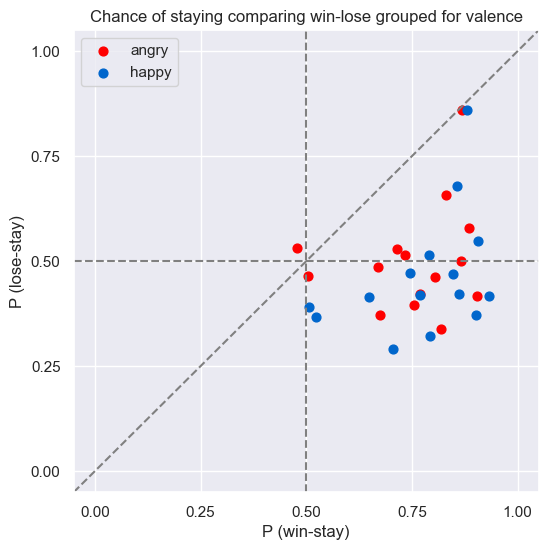

In [10]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#FF0000', '#0066CC']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [11]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session volatility  p_win_stay  p_lose_stay
0     sub-900  session-01     stable    0.804598     0.299213
1     sub-900  session-01   volatile    0.808081     0.355263
2     sub-901  session-01     stable    0.679104     0.422018
3     sub-901  session-01   volatile    0.647619     0.462687
4     sub-902  session-01     stable    0.612903     0.495868
5     sub-902  session-01   volatile    0.450262     0.380952
6     sub-903  session-01     stable    0.477612     0.507692
7     sub-903  session-01   volatile    0.502591     0.429319
8     sub-904  session-01     stable    0.711656     0.485075
9     sub-904  session-01   volatile    0.790816     0.557971
10    sub-905  session-01     stable    0.690789     0.458333
11    sub-905  session-01   volatile    0.790123     0.478528
12    sub-906  session-01     stable    0.754902     0.824675
13    sub-906  session-01   volatile    0.923695     0.895062
14    sub-907  session-01     stable    0.883041     0.500000
15    su

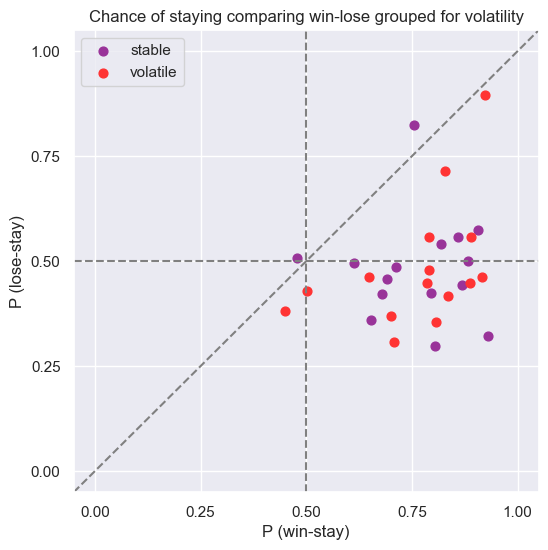

In [12]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [13]:
# First combine two columns
grouping_factor = 'congruency'
dataframe_valence_volatility = dataframe_with_volatility

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency  p_win_stay  p_lose_stay
0     sub-900  session-01    congruent    0.753012     0.362319
1     sub-900  session-01  incongruent    0.849515     0.297872
2     sub-901  session-01    congruent    0.562130     0.450867
3     sub-901  session-01  incongruent    0.754286     0.445255
4     sub-902  session-01    congruent    0.570513     0.436242
5     sub-902  session-01  incongruent    0.459119     0.408867
6     sub-903  session-01    congruent    0.512500     0.435583
7     sub-903  session-01  incongruent    0.473054     0.487342
8     sub-904  session-01    congruent    0.757576     0.476923
9     sub-904  session-01  incongruent    0.751553     0.563380
10    sub-905  session-01    congruent    0.792208     0.460870
11    sub-905  session-01  incongruent    0.695122     0.479167
12    sub-906  session-01    congruent    0.919231     0.700000
13    sub-906  session-01  incongruent    0.747253     0.924779
14    sub-907  session-01    congruent  

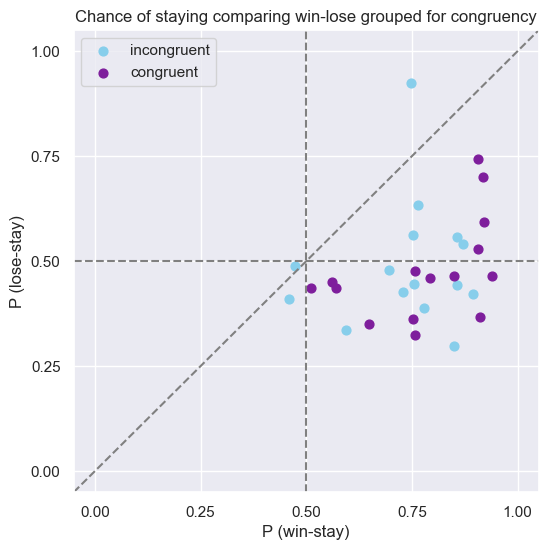

In [14]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_congruency_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [15]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session valence_volatility  p_win_stay  p_lose_stay
0     sub-900  session-01     angry & stable    0.831461     0.278689
1     sub-900  session-01   angry & volatile    0.808511     0.384615
2     sub-900  session-01     happy & stable    0.776471     0.318182
3     sub-900  session-01   happy & volatile    0.807692     0.324324
4     sub-901  session-01     angry & stable    0.733333     0.413043
5     sub-901  session-01   angry & volatile    0.625000     0.520000
6     sub-901  session-01     happy & stable    0.610169     0.428571
7     sub-901  session-01   happy & volatile    0.669811     0.405941
8     sub-902  session-01     angry & stable    0.600000     0.562500
9     sub-902  session-01   angry & volatile    0.436782     0.416000
10    sub-902  session-01     happy & stable    0.625000     0.421053
11    sub-902  session-01   happy & volatile    0.461538     0.339623
12    sub-903  session-01     angry & stable    0.500000     0.539683
13    sub-903  sessi

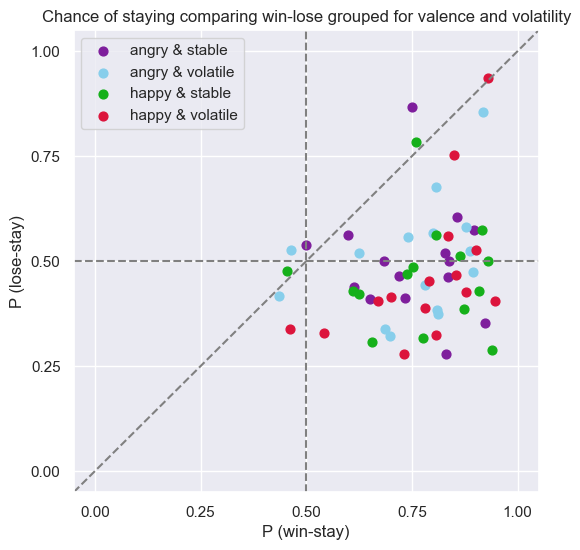

In [16]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [17]:
# First combine two columns
grouping_factor_1 = 'congruency'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the WSLS values for the staying condition
WSLS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 1) & (dataframe_valence_volatility.WSLS != 2)].index, inplace=False)
WSLS_dataframe_win_p['WSLS'] = WSLS_dataframe_win_p['WSLS'] - 1
WSLS_win_p_averages = WSLS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then do the same for the shifting condition
WSLS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.WSLS != 3) & (dataframe_valence_volatility.WSLS != 4)].index, inplace=False)
WSLS_dataframe_lose_p['WSLS'] = WSLS_dataframe_lose_p['WSLS'] - 3
WSLS_lose_p_averages = WSLS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['WSLS'].mean().reset_index()

# Then combine the two and rename the WSLS columns
WSLS_dataframe_averages = WSLS_win_p_averages[['subject_id', 'session', grouping_factor]]
WSLS_dataframe_averages['p_win_stay'] = WSLS_win_p_averages['WSLS']
WSLS_dataframe_averages['p_lose_stay'] = WSLS_lose_p_averages['WSLS']
print(WSLS_dataframe_averages)

   subject_id     session   congruency_volatility  p_win_stay  p_lose_stay
0     sub-900  session-01      congruent & stable    0.736842     0.355263
1     sub-900  session-01    congruent & volatile    0.774648     0.370968
2     sub-900  session-01    incongruent & stable    0.886076     0.215686
3     sub-900  session-01  incongruent & volatile    0.826772     0.344444
4     sub-901  session-01      congruent & stable    0.533333     0.375000
5     sub-901  session-01    congruent & volatile    0.568345     0.473684
6     sub-901  session-01    incongruent & stable    0.721154     0.449275
7     sub-901  session-01  incongruent & volatile    0.802817     0.441176
8     sub-902  session-01      congruent & stable    0.682927     0.523810
9     sub-902  session-01    congruent & volatile    0.445946     0.323077
10    sub-902  session-01    incongruent & stable    0.476190     0.432432
11    sub-902  session-01  incongruent & volatile    0.452991     0.403614
12    sub-903  session-01

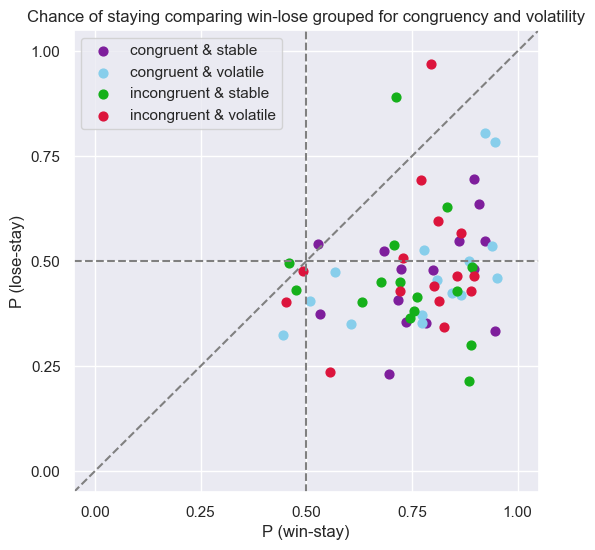

In [18]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = WSLS_dataframe_averages['congruency_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = WSLS_dataframe_averages.drop(WSLS_dataframe_averages[WSLS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_win_stay'], filtered_dataframe['p_lose_stay'], color=scatterplot_colours[index], label=value, s=40)

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (win-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (lose-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing win-lose grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(WSLS_output_dir, f'{plot_name}.pdf'))
plt.show()

# Check congruency, valence and volatility
### For CSIS (congruent-stay/incongruent-switch)

In [19]:
# Check a block's congruency
dataframe_CSIS['congruency'] = dataframe_CSIS.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
dataframe_CSIS['valence'] = dataframe_CSIS.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
dataframe_CSIS = dataframe_CSIS[dataframe_CSIS['probability_condition'] != 50]
dataframe_with_volatility = dataframe_CSIS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)
dataframe_with_volatility = dataframe_with_volatility.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
dataframe_with_volatility.reset_index(drop=True, inplace=True)
print(dataframe_with_volatility[['subject_id', 'session', 'congruency', 'valence', 'volatility', 'CSIS']])

unique_valence_conditions = dataframe_with_volatility['valence'].unique()
unique_congruency_conditions = dataframe_with_volatility['congruency'].unique()
unique_volatility_conditions = dataframe_with_volatility['volatility'].unique()

dataframe_without_volatility = dataframe_CSIS

      subject_id     session   congruency valence volatility  CSIS
0        sub-900  session-01  incongruent   angry     stable     4
1        sub-900  session-01  incongruent   angry     stable     4
2        sub-900  session-01  incongruent   angry     stable     3
3        sub-900  session-01  incongruent   angry     stable     3
4        sub-900  session-01  incongruent   angry     stable     3
...          ...         ...          ...     ...        ...   ...
10071    sub-914  session-01    congruent   happy     stable     1
10072    sub-914  session-01    congruent   happy     stable     1
10073    sub-914  session-01    congruent   happy     stable     1
10074    sub-914  session-01    congruent   happy     stable     1
10075    sub-914  session-01    congruent   happy     stable     1

[10076 rows x 6 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_2635/1031595679.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_with_volatility = dataframe_CSIS.groupby('stimuli_type', group_keys=False).apply(utils.analysis_functions.check_volatility)


# Plot the CSIS separately for staying and shifting
- Volatility
- Valence
- Valence/Volatility

In [20]:
# First combine two columns
grouping_factor = 'volatility'
dataframe_valence_volatility = dataframe_with_volatility

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session volatility  p_congruent_stay  p_incongruent_stay
0     sub-900  session-01     stable          0.448864            0.381679
1     sub-900  session-01   volatile          0.442857            0.392857
2     sub-901  session-01     stable          0.592105            0.397727
3     sub-901  session-01   volatile          0.492857            0.378571
4     sub-902  session-01     stable          0.404762            0.550000
5     sub-902  session-01   volatile          0.614286            0.577465
6     sub-903  session-01     stable          0.486842            0.526042
7     sub-903  session-01   volatile          0.561538            0.548611
8     sub-904  session-01     stable          0.478571            0.413043
9     sub-904  session-01   volatile          0.344340            0.316176
10    sub-905  session-01     stable          0.381579            0.420455
11    sub-905  session-01   volatile          0.325000            0.421429
12    sub-906  session-01

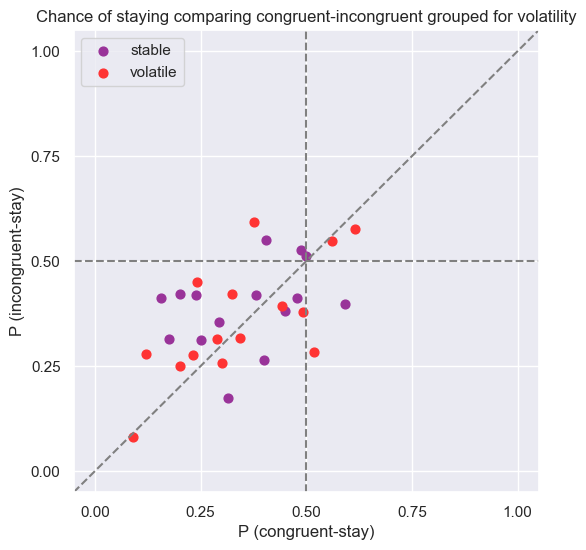

In [21]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#993399', '#FF3333']

for index, value in enumerate(unique_volatility_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [22]:
# First combine two columns
grouping_factor = 'valence'
dataframe_valence_volatility = dataframe_with_volatility

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session valence  p_congruent_stay  p_incongruent_stay
0     sub-900  session-01   angry          0.468354            0.365169
1     sub-900  session-01   happy          0.424051            0.412429
2     sub-901  session-01   angry          0.516854            0.335443
3     sub-901  session-01   happy          0.511236            0.443038
4     sub-902  session-01   angry          0.487013            0.543956
5     sub-902  session-01   happy          0.512987            0.598901
6     sub-903  session-01   angry          0.488095            0.535714
7     sub-903  session-01   happy          0.601190            0.535714
8     sub-904  session-01   angry          0.443182            0.393750
9     sub-904  session-01   happy          0.352273            0.350000
10    sub-905  session-01   angry          0.275281            0.493671
11    sub-905  session-01   happy          0.398876            0.348101
12    sub-906  session-01   angry          0.160000            0

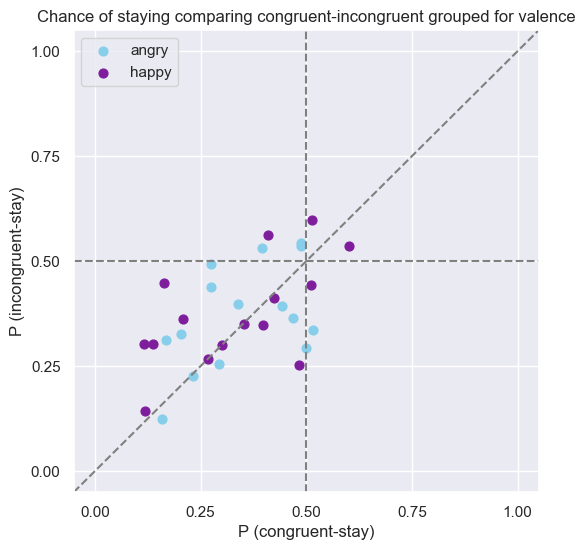

In [23]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#87CEEB', '#7E1E9C']

for index, value in enumerate(unique_valence_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)


# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()

In [24]:
# First combine two columns
grouping_factor_1 = 'valence'
grouping_factor_2 = 'volatility'
grouping_factor = f'{grouping_factor_1}_{grouping_factor_2}'
dataframe_valence_volatility = dataframe_with_volatility
dataframe_valence_volatility[grouping_factor] = dataframe_valence_volatility[grouping_factor_1] + ' & ' + dataframe_valence_volatility[grouping_factor_2]

# Average the CSIS values for the staying condition
CSIS_dataframe_win_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 1) & (dataframe_valence_volatility.CSIS != 2)].index, inplace=False)
CSIS_dataframe_win_p['CSIS'] = CSIS_dataframe_win_p['CSIS'] - 1
CSIS_win_p_averages = CSIS_dataframe_win_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then do the same for the shifting condition
CSIS_dataframe_lose_p = dataframe_valence_volatility.drop(dataframe_valence_volatility[(dataframe_valence_volatility.CSIS != 3) & (dataframe_valence_volatility.CSIS != 4)].index, inplace=False)
CSIS_dataframe_lose_p['CSIS'] = CSIS_dataframe_lose_p['CSIS'] - 3
CSIS_lose_p_averages = CSIS_dataframe_lose_p.groupby(['subject_id', 'session', grouping_factor])['CSIS'].mean().reset_index()

# Then combine the two and rename the CSIS columns
CSIS_dataframe_averages = CSIS_win_p_averages[['subject_id', 'session', grouping_factor]]
CSIS_dataframe_averages['p_congruent_stay'] = CSIS_win_p_averages['CSIS']
CSIS_dataframe_averages['p_incongruent_stay'] = CSIS_lose_p_averages['CSIS']
print(CSIS_dataframe_averages)

   subject_id     session valence_volatility  p_congruent_stay  \
0     sub-900  session-01     angry & stable          0.454545   
1     sub-900  session-01   angry & volatile          0.485714   
2     sub-900  session-01     happy & stable          0.443182   
3     sub-900  session-01   happy & volatile          0.400000   
4     sub-901  session-01     angry & stable          0.605263   
5     sub-901  session-01   angry & volatile          0.492857   
6     sub-901  session-01     happy & stable          0.578947   
7     sub-901  session-01   happy & volatile          0.492857   
8     sub-902  session-01     angry & stable          0.380952   
9     sub-902  session-01   angry & volatile          0.614286   
10    sub-902  session-01     happy & stable          0.428571   
11    sub-902  session-01   happy & volatile          0.614286   
12    sub-903  session-01     angry & stable          0.447368   
13    sub-903  session-01   angry & volatile          0.500000   
14    sub-

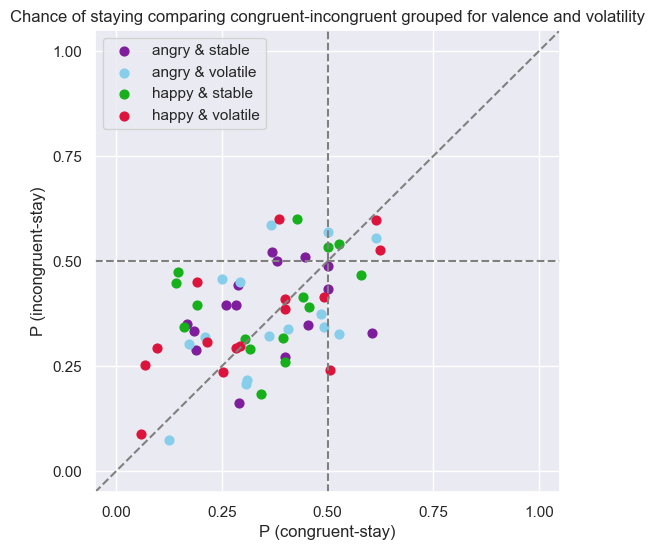

In [25]:
# Plot everything in a scatterplot
fig, ax = plt.subplots(figsize=(6, 6))
scatterplot_colours = ['#7E1E9C', '#87CEEB', '#15B01A', '#DC143C']
unique_conditions = CSIS_dataframe_averages['valence_volatility'].unique()

for index, value in enumerate(unique_conditions):
    filtered_dataframe = CSIS_dataframe_averages.drop(CSIS_dataframe_averages[CSIS_dataframe_averages[grouping_factor] != value].index, inplace=False)
    ax.scatter(filtered_dataframe['p_congruent_stay'], filtered_dataframe['p_incongruent_stay'], color=scatterplot_colours[index], label=value, s=40)

# Plotting extra lines
ax.axhline(0.5, color='grey', linestyle='dashed')
ax.axvline(0.5, color='grey', linestyle='dashed')
ax.axline([0, 0], [1, 1], color='grey', linestyle='dashed')

# Adding labels and title
ax.set_xlabel('P (congruent-stay)')
ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
ax.set_ylabel('P (incongruent-stay)')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

plot_name = f'Chance of staying comparing congruent-incongruent grouped for {grouping_factor_1} and {grouping_factor_2}'
ax.set_title(plot_name)
ax.legend()

plt.savefig(os.path.join(CSIS_output_dir, f'{plot_name}.pdf'))
plt.show()